# Artificial Intelligence Technology and Application

## Deep Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 MobileNetV2 Image Classification

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Transfer Learning Shape Flow
A synthetic image tensor demonstrates the same train/validation split without a large download.


In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(33)
class_names = np.array(["daisy", "dandelion", "rose", "sunflower", "tulip"])
labels = np.repeat(np.arange(5), 24)
base_colors = np.array([
    [0.8, 0.8, 0.2], [0.9, 0.7, 0.1], [0.8, 0.2, 0.3], [1.0, 0.75, 0.05], [0.6, 0.2, 0.8]
])
images = base_colors[labels][:, None, None, :] + rng.normal(0, 0.12, size=(labels.size, 16, 16, 3))
images = images.clip(0, 1)
train_img, val_img, train_y, val_y = train_test_split(images, labels, stratify=labels, random_state=33)
print("train tensor:", train_img.shape, "validation tensor:", val_img.shape)


train tensor: (90, 16, 16, 3) validation tensor: (30, 16, 16, 3)


## 1.2 Frozen Feature Extractor
Mean, standard deviation, and channel contrast act as compact image embeddings.


In [2]:
def extract_features(batch):
    means = batch.mean(axis=(1, 2))
    stds = batch.std(axis=(1, 2))
    contrast = batch.max(axis=(1, 2)) - batch.min(axis=(1, 2))
    return np.concatenate([means, stds, contrast], axis=1)

train_features = extract_features(train_img)
val_features = extract_features(val_img)
print("feature shape:", train_features.shape)


feature shape: (90, 9)


## 1.3 Classification Head
Only the final classifier is trained, matching the transfer-learning idea.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

head = LogisticRegression(max_iter=500).fit(train_features, train_y)
predicted = head.predict(val_features)
print("transfer-style accuracy:", round(accuracy_score(val_y, predicted), 3))
print(list(zip(class_names[val_y[:8]], class_names[predicted[:8]])))


transfer-style accuracy: 0.9
[(np.str_('tulip'), np.str_('tulip')), (np.str_('sunflower'), np.str_('sunflower')), (np.str_('sunflower'), np.str_('sunflower')), (np.str_('dandelion'), np.str_('sunflower')), (np.str_('daisy'), np.str_('daisy')), (np.str_('sunflower'), np.str_('sunflower')), (np.str_('tulip'), np.str_('tulip')), (np.str_('dandelion'), np.str_('dandelion'))]


## 1.4 Visual Samples
Predictions are displayed on synthetic validation images.


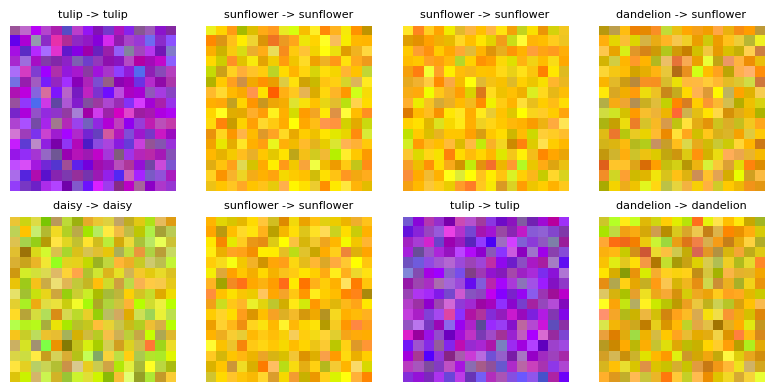

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, image, truth, pred in zip(axes.ravel(), val_img[:8], val_y[:8], predicted[:8]):
    ax.imshow(image)
    ax.set_title(f"{class_names[truth]} -> {class_names[pred]}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()
